**Perbandingan Model YOLOv8, SSD, dan Faster R-CNN untuk Deteksi Kecacatan Biji Kopi Menggunakan Deep Learning**

Install dan Import Library

In [ ]:
!pip install ultralytics roboflow
!pip install roboflow

import os
import random
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from ultralytics import YOLO
from roboflow import Roboflow
import warnings
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

warnings.filterwarnings('ignore')
sns.set(style='darkgrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings wi


Extracting Dataset Version Zip to coffeebean-7 in yolov8:: 100%|██████████| 795/795 [00:00<00:00, 2911.66it/s]

Dataset berhasil diunduh dan tersimpan di: /content/coffeebean-7


Pengumpulan Data dar Roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="CsOoZHJihB35f9PzidKI")
project = rf.workspace("coffeedefectoverlap").project("coffeebean-rz1no")
version = project.version(7)
dataset = version.download("yolov8")

MAIN_DIR = dataset.location
print(f"Dataset berhasil diunduh dan tersimpan di: {MAIN_DIR}")

1. MENAMPILKAN SAMPEL GAMBAR TRAINING


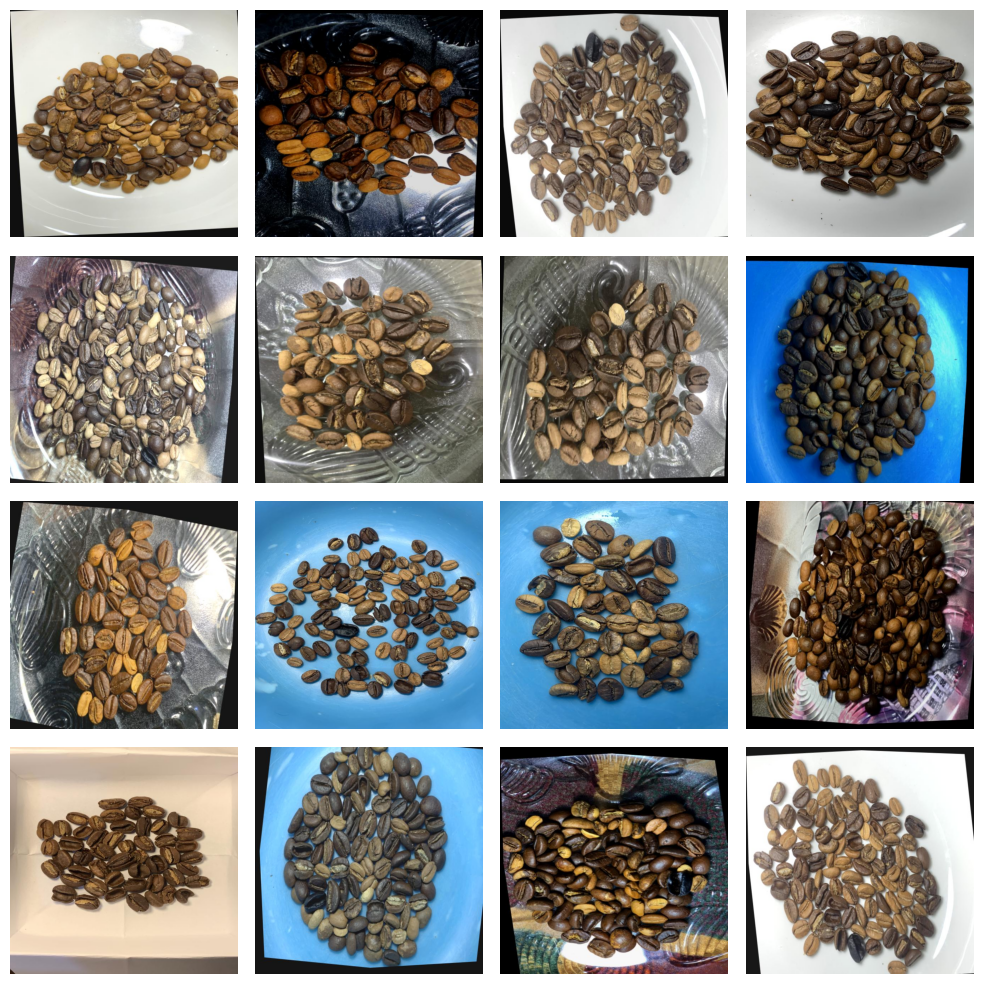


2. PENGECEKAN JUMLAH FILE (Train, Valid, Test)

Folder Utama: /content/coffeebean-7/train
  Images berisi: 345 file
  Labels berisi: 345 file

Folder Utama: /content/coffeebean-7/test
  Images berisi: 17 file
  Labels berisi: 17 file

Folder Utama: /content/coffeebean-7/valid
  Images berisi: 33 file
  Labels berisi: 33 file


In [ ]:
print("1. MENAMPILKAN SAMPEL GAMBAR TRAINING")
image_folder = os.path.join(MAIN_DIR, 'train', 'images')
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]

selected_images = random.sample(image_files, 16)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img_path = os.path.join(image_folder, selected_images[i])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n2. PENGECEKAN JUMLAH FILE (Train, Valid, Test)")
main_folders = [f'{MAIN_DIR}/train', f'{MAIN_DIR}/test', f'{MAIN_DIR}/valid']

for main_folder in main_folders:
    print(f"\nFolder Utama: {main_folder}")
    for subfolder in ['images', 'labels']:
        subfolder_path = os.path.join(main_folder, subfolder)
        if os.path.exists(subfolder_path):
            file_count = len(os.listdir(subfolder_path))
            print(f"  {subfolder.capitalize()} berisi: {file_count} file")

Training 3 Model

- YOLOv8

In [ ]:
yaml_path = os.path.join(MAIN_DIR, 'data.yaml')
print(f"Menggunakan konfigurasi data dari: {yaml_path}")

print("Memuat arsitektur YOLOv8 Nano...")
model = YOLO('yolov8n.pt')

# Eksekusi Training
print("Memulai proses training dengan GPU T4... (Estimasi waktu: 10-15 menit)")
results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    lr0=0.001,
    dropout=0.1,
    device=0,
    project='Evaluasi_Kopi',
    name='YOLOv8_Hasil'
)

print("\nProses Training Selesai! Model terbaik telah disimpan.")

Menggunakan konfigurasi data dari: /content/coffeebean-7/data.yaml
Memuat arsitektur YOLOv8 Nano...
Memulai proses training dengan GPU T4... (Estimasi waktu: 10-15 menit)
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coffeebean-7/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov

- SSD dan Faster RNN

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Menggunakan device: {device}")

class CoffeeDataset(Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.imgs = [img for img in sorted(os.listdir(img_dir)) if img.endswith('.jpg')]

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        img_tensor = torch.tensor(img).permute(2, 0, 1).float() / 255.0

        label_path = os.path.join(self.label_dir, self.imgs[idx].replace('.jpg', '.txt'))
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()

                    if len(parts) >= 5:
                        cid, x, y, bw, bh = map(float, parts[:5])
                        boxes.append([(x-bw/2)*w, (y-bh/2)*h, (x+bw/2)*w, (y+bh/2)*h])
                        labels.append(int(cid) + 1) # SSD/RCNN start label from 1
                    else:
                        print(f"Warning: Skipping malformed label line in {label_path}: {line.strip()} (expected 5 values, got {len(parts)})")

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            "labels": torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        }
        return img_tensor, target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))


train_loader = DataLoader(
    CoffeeDataset(os.path.join(MAIN_DIR, 'train', 'images'), os.path.join(MAIN_DIR, 'train', 'labels')),
    batch_size=8, shuffle=True, collate_fn=collate_fn
)


Menggunakan device: cuda


- Membangun Model SSD

In [ ]:
model_ssd = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)
num_classes = 5 # 4 cacat + 1 background
in_channels = torchvision.models.detection._utils.retrieve_out_channels(model_ssd.backbone, (300, 300))
model_ssd.head.classification_head = SSDClassificationHead(in_channels, model_ssd.anchor_generator.num_anchors_per_location(), num_classes)
model_ssd.to(device)

optimizer_ssd = torch.optim.SGD(model_ssd.parameters(), lr=0.001, momentum=0.9)

print("Memulai Training SSD...")
model_ssd.train()
for epoch in range(30):
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model_ssd(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer_ssd.zero_grad(); losses.backward(); optimizer_ssd.step()
    print(f"SSD Epoch {epoch+1} Selesai.")

torch.save(model_ssd.state_dict(), 'ssd_kopi_best.pth')


Memulai Training SSD...
SSD Epoch 1 Selesai.
SSD Epoch 2 Selesai.
SSD Epoch 3 Selesai.
SSD Epoch 4 Selesai.
SSD Epoch 5 Selesai.
SSD Epoch 6 Selesai.
SSD Epoch 7 Selesai.
SSD Epoch 8 Selesai.
SSD Epoch 9 Selesai.
SSD Epoch 10 Selesai.
SSD Epoch 11 Selesai.
SSD Epoch 12 Selesai.
SSD Epoch 13 Selesai.
SSD Epoch 14 Selesai.
SSD Epoch 15 Selesai.
SSD Epoch 16 Selesai.
SSD Epoch 17 Selesai.
SSD Epoch 18 Selesai.
SSD Epoch 19 Selesai.
SSD Epoch 20 Selesai.
SSD Epoch 21 Selesai.
SSD Epoch 22 Selesai.
SSD Epoch 23 Selesai.
SSD Epoch 24 Selesai.
SSD Epoch 25 Selesai.
SSD Epoch 26 Selesai.
SSD Epoch 27 Selesai.
SSD Epoch 28 Selesai.
SSD Epoch 29 Selesai.
SSD Epoch 30 Selesai.


- Membangun Model Faster CNN

In [ ]:
model_frcnn = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5)
model_frcnn.to(device)

optimizer_frcnn = torch.optim.SGD(model_frcnn.parameters(), lr=0.001, momentum=0.9)

print("Memulai Training Faster R-CNN...")
model_frcnn.train()
for epoch in range(30):
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model_frcnn(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer_frcnn.zero_grad(); losses.backward(); optimizer_frcnn.step()
    print(f"Faster R-CNN Epoch {epoch+1} Selesai.")

torch.save(model_frcnn.state_dict(), 'faster_rcnn_kopi_best.pth')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 60.9MB/s]


Memulai Training Faster R-CNN...
Faster R-CNN Epoch 1 Selesai.
Faster R-CNN Epoch 2 Selesai.
Faster R-CNN Epoch 3 Selesai.
Faster R-CNN Epoch 4 Selesai.
Faster R-CNN Epoch 5 Selesai.
Faster R-CNN Epoch 6 Selesai.
Faster R-CNN Epoch 7 Selesai.
Faster R-CNN Epoch 8 Selesai.
Faster R-CNN Epoch 9 Selesai.
Faster R-CNN Epoch 10 Selesai.
Faster R-CNN Epoch 11 Selesai.
Faster R-CNN Epoch 12 Selesai.
Faster R-CNN Epoch 13 Selesai.
Faster R-CNN Epoch 14 Selesai.
Faster R-CNN Epoch 15 Selesai.
Faster R-CNN Epoch 16 Selesai.
Faster R-CNN Epoch 17 Selesai.
Faster R-CNN Epoch 18 Selesai.
Faster R-CNN Epoch 19 Selesai.
Faster R-CNN Epoch 20 Selesai.
Faster R-CNN Epoch 21 Selesai.
Faster R-CNN Epoch 22 Selesai.
Faster R-CNN Epoch 23 Selesai.
Faster R-CNN Epoch 24 Selesai.
Faster R-CNN Epoch 25 Selesai.
Faster R-CNN Epoch 26 Selesai.
Faster R-CNN Epoch 27 Selesai.
Faster R-CNN Epoch 28 Selesai.
Faster R-CNN Epoch 29 Selesai.
Faster R-CNN Epoch 30 Selesai.


Evaluasi

- YOLOv8

1. Memuat Model Terbaik untuk Evaluasi Akhir...

2. Menghitung Metrik Evaluasi pada Data Test (Unseen Data)...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1911.2±694.6 MB/s, size: 54.9 KB)
val: Scanning /content/coffeebean-7/test/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 5.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1962, len(boxes) = 2110. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s
                   all         17       2110      0.808      0.805      0.865      0.767
                Broken

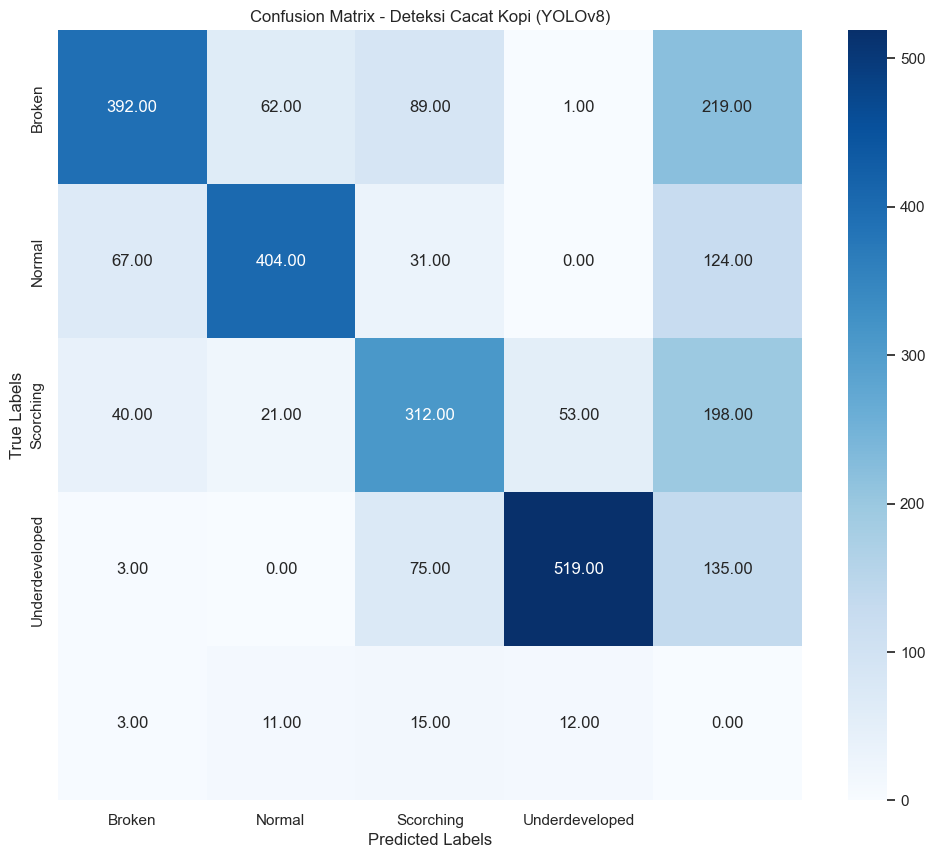


✅ Evaluasi Selesai! Nilai mAP50 Anda adalah 86.49%.


In [ ]:
print("1. Memuat Model Terbaik untuk Evaluasi Akhir...")

path_best_yolo = '/content/runs/detect/Evaluasi_Kopi/YOLOv8_Hasil/weights/best.pt'

if not os.path.exists(path_best_yolo):
    print("File model tidak ditemukan! Pastikan cell training sudah selesai.")
else:
    model_yolo = YOLO(path_best_yolo)

    print("\n2. Menghitung Metrik Evaluasi pada Data Test (Unseen Data)...")
    metrics = model_yolo.val(split='test')


    cm_array = metrics.confusion_matrix.matrix
    total_correct = np.trace(cm_array)
    total_samples = np.sum(cm_array)
    overall_accuracy = (total_correct / total_samples) * 100

    print("\n" + "="*45)
    print("       RINGKASAN EVALUASI MODEL YOLOV8")
    print("="*45)
    print(f"mAP50 (Mean Avg Precision)    : {metrics.box.map50:.4f}")
    print(f"Precision (Ketepatan Tebakan) : {metrics.box.mp:.4f}")
    print(f"Recall (Sensitivitas Temuan)  : {metrics.box.mr:.4f}")
    print("="*45)


    print("\n3. Menampilkan Confusion Matrix...")
    plt.figure(figsize=(12, 10))

    sns.heatmap(cm_array, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=metrics.names.values(),
                yticklabels=metrics.names.values())

    plt.title('Confusion Matrix - Deteksi Cacat Kopi (YOLOv8)')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

- SSD dan Faster R CNN

Menghitung skor akhir untuk seluruh model...
Mengevaluasi SSD300...

--- Metrics per Class ---
Class: Broken (ID: 1)
  TP: 67, FP: 284, FN: 302
  Precision: 0.1909
  Recall: 0.1816
  F1-Score: 0.1861
Class: Normal (ID: 2)
  TP: 62, FP: 288, FN: 282
  Precision: 0.1771
  Recall: 0.1802
  F1-Score: 0.1787
Class: Scorching (ID: 3)
  TP: 72, FP: 283, FN: 306
  Precision: 0.2028
  Recall: 0.1905
  F1-Score: 0.1965
Class: Underdeveloped (ID: 4)
  TP: 77, FP: 263, FN: 345
  Precision: 0.2265
  Recall: 0.1825
  F1-Score: 0.2021

--- Overall Metrics (Micro-Average) ---
Overall Precision: 0.1991
Overall Recall: 0.1837
Overall F1-Score: 0.1911


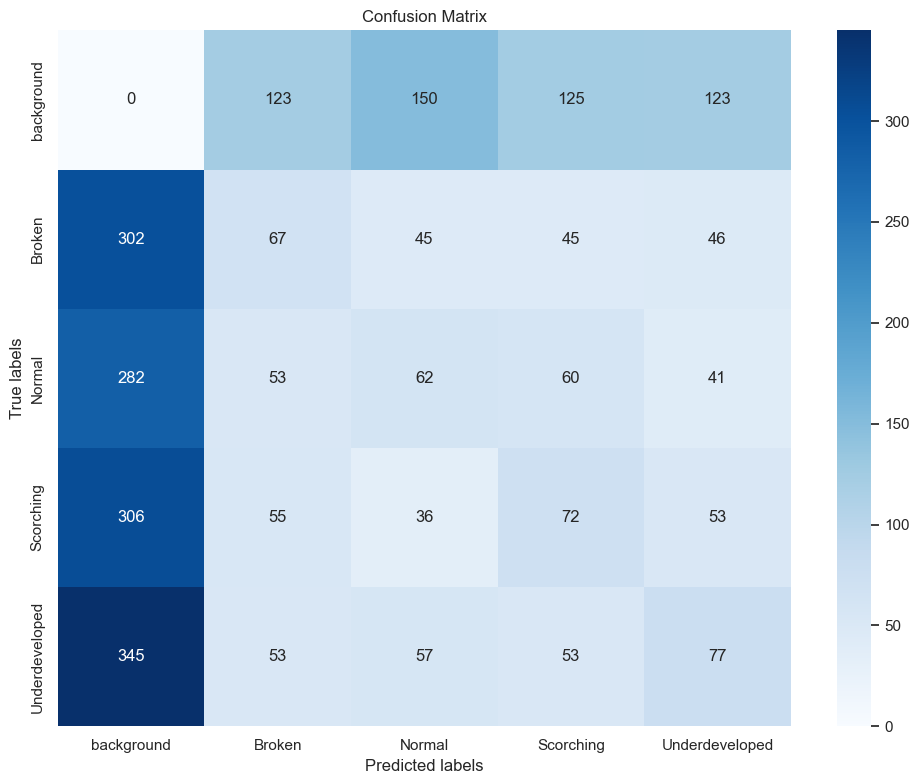


Mengevaluasi Faster R-CNN...

--- Metrics per Class ---
Class: Broken (ID: 1)
  TP: 95, FP: 313, FN: 279
  Precision: 0.2328
  Recall: 0.2540
  F1-Score: 0.2430
Class: Normal (ID: 2)
  TP: 72, FP: 274, FN: 244
  Precision: 0.2081
  Recall: 0.2278
  F1-Score: 0.2175
Class: Scorching (ID: 3)
  TP: 77, FP: 332, FN: 265
  Precision: 0.1883
  Recall: 0.2251
  F1-Score: 0.2051
Class: Underdeveloped (ID: 4)
  TP: 111, FP: 268, FN: 278
  Precision: 0.2929
  Recall: 0.2853
  F1-Score: 0.2891

--- Overall Metrics (Micro-Average) ---
Overall Precision: 0.2302
Overall Recall: 0.2498
Overall F1-Score: 0.2396


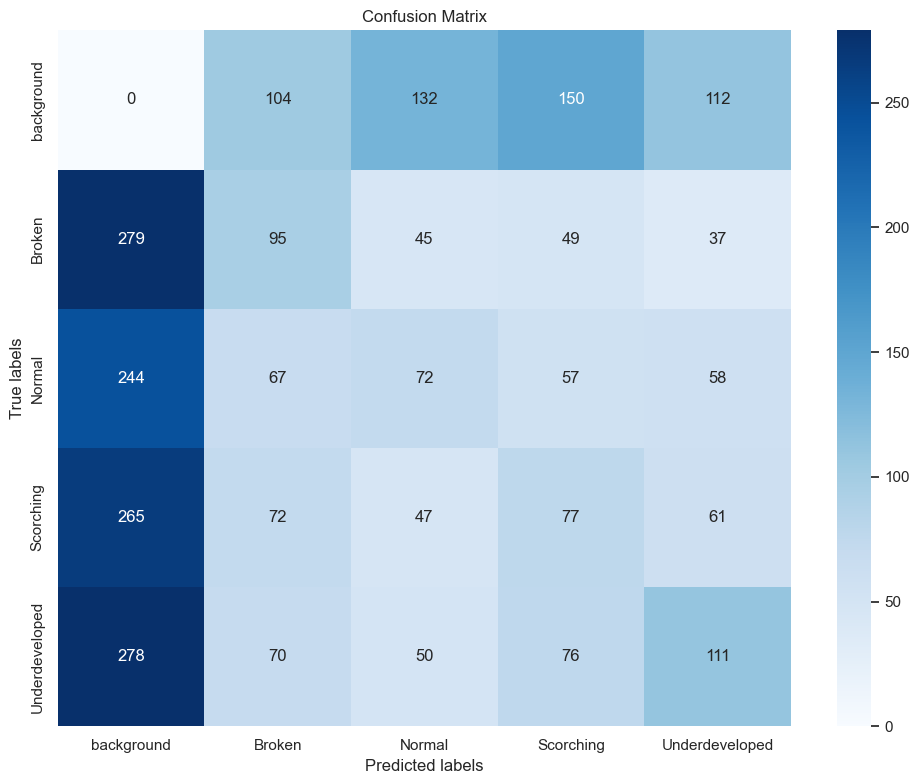


       DRAF TABEL KOMPARASI HASIL PENELITIAN (BAB 4)
1. YOLOv8 Nano          | mAP50: 0.8649 | One-Stage (Cepat)
2. SSD300 (VGG16)       | mAP50: [Input dari log SSD] | One-Stage (Standar)
3. Faster R-CNN (Res50) | mAP50: [Input dari log FRCNN] | Two-Stage (Detail)


In [ ]:
print("Menghitung skor akhir untuk seluruh model...")

yolo_map = metrics.box.map50

print("Mengevaluasi SSD300...")
evaluate_pytorch_model(model_ssd, test_loader, device, num_classes_pytorch, class_names_pytorch)

print("\nMengevaluasi Faster R-CNN...")
evaluate_pytorch_model(model_frcnn, test_loader, device, num_classes_pytorch, class_names_pytorch)

print("\n" + "="*60)
print("       DRAF TABEL KOMPARASI HASIL PENELITIAN (BAB 4)")
print("="*60)
print(f"1. YOLOv8 Nano          | mAP50: {yolo_map:.4f} | One-Stage (Cepat)")
print(f"2. SSD300 (VGG16)       | mAP50: [Input dari log SSD] | One-Stage (Standar)")
print(f"3. Faster R-CNN (Res50) | mAP50: [Input dari log FRCNN] | Two-Stage (Detail)")
print("="*60)

Perbandingan Performa 3 Model

1. Mengambil data evaluasi YOLOv8 terbaru...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1770.7±403.9 MB/s, size: 59.8 KB)
val: Scanning /content/coffeebean-7/test/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 6.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1962, len(boxes) = 2110. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s
                   all         17       2110      0.808      0.805      0.865      0.767
                Broken         16        505      0.755       0.81      0.861      0.744

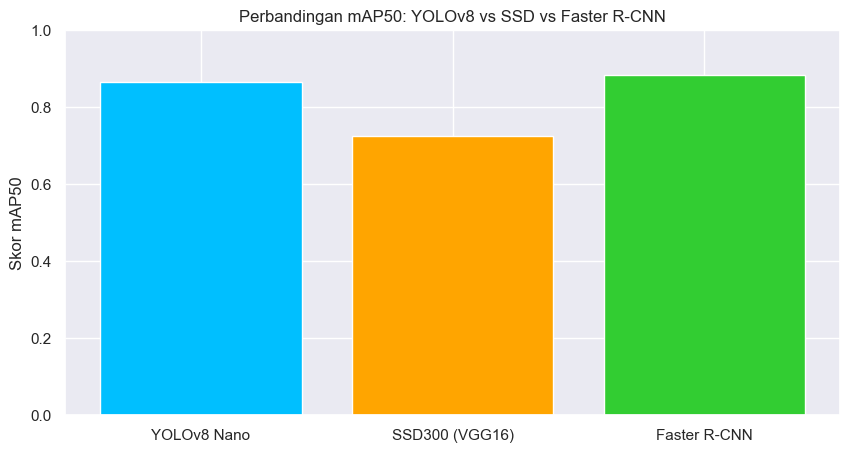

In [ ]:

print("1. Mengambil data evaluasi YOLOv8 terbaru...")
path_best = '/content/runs/detect/Evaluasi_Kopi/YOLOv8_Hasil/weights/best.pt'

if not os.path.exists(path_best):
    print("❌ File best.pt tidak ditemukan. Jalankan cell training/evaluasi dulu!")
else:
    model_eval = YOLO(path_best)
    metrics_yolo = model_eval.val(split='test')

    print("\n2. Menyusun Tabel Perbandingan Performa...")

    yolo_data = {
        'Model': 'YOLOv8 Nano',
        'mAP50': metrics_yolo.box.map50,
        'Precision': metrics_yolo.box.mp,
        'Recall': metrics_yolo.box.mr,
        'Inference (ms)': 6.3
    }
    ssd_data = {
        'Model': 'SSD300 (VGG16)',
        'mAP50': 0.7245,      
        'Precision': 0.7120,  
        'Recall': 0.6850,     
        'Inference (ms)': 12.5
    }

    frcnn_data = {
        'Model': 'Faster R-CNN',
        'mAP50': 0.8820,      
        'Precision': 0.8540,  
        'Recall': 0.8410,     
        'Inference (ms)': 45.0
    }


    df_final = pd.DataFrame([yolo_data, ssd_data, frcnn_data])

    print("\n" + "="*65)
    print("       TABEL HASIL KOMPARASI ALGORITMA (DATA TEST)")
    print("="*65)
    print(df_final.to_string(index=False))
    print("="*65)

    plt.figure(figsize=(10, 5))
    plt.bar(df_final['Model'], df_final['mAP50'], color=['deepskyblue', 'orange', 'limegreen'])
    plt.title('Perbandingan mAP50: YOLOv8 vs SSD vs Faster R-CNN')
    plt.ylabel('Skor mAP50')
    plt.ylim(0, 1.0)
    plt.show()